## 질문

레벨6과 레벨7 사이(6.5)는 어떤 연봉이 합리적일까?

STEP#1 - 라이브러리 임포트

In [60]:
# pandas, numpy, sklearn, matplotlib

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

STEP#2 - 데이터 불러오기<br>
X: 입력 ( feature ) - level( 직급 단계 ) - 2차원<br>
y: 정답( target or label ) = Salary( 연봉 )<br>

In [ ]:
df = pd.read_csv('../../data/Position_Salaries.csv')
# 첫번째: 컬럼 -> 전체 행임, 두번쟤: 열 - 1번 인덱스 부터 마지막 전까지
X = df.iloc[:, 1:-1].values
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [67]:
# 첫번째 행은 컬럼명 이기 때문에 필요가 없음
y = df.iloc[:, -1].values
# y축은 행이므로 skip
# 1번째 부터 마지막 까지
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

STEP#3 - 학습데이터 / 테스트 데이터 분리

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) # 알고리즘 훈련시킴

STEP#4 - 모델 준비( 심화학습 - 비교실습 )

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

models = {
  #1 단순선형 회귀
  'LinearRegression': LinearRegression(),
  #2 다항회귀
  'Polynomial(2차)': Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
  ]),
  #3 의사결정 회귀
  'Decisiontree(d=3)': DecisionTreeRegressor(max_depth=3, random_state=0)
}

STEP#5 - 학습 + 평가

In [77]:
from sklearn.metrics import mean_squared_error, r2_score
# 3가지 모델 중에서 어떤 모델이 적절한가에 대해서는 결정계수를 확인해 보면 됨. 
def evaluate(name, model):
  model.fit(X_train, y_train)
  # 테스트 세트 예측
  pred = model.predict(X_test)
  # 평균제곱오차(MSE)
  mse = mean_squared_error(y_test, pred)
  r2 = r2_score(y_test, pred)
  print(f"\n[{name}]")
  print("MSE : ", round(mse, 2))
  print("R2 : ", round(r2, 4))
  return model # 학습시킨 모델 반환(아래에서 시각화에 재사용할 것임)

# models 딕셔너리 순회하면서 각 모델을 학습, 평가하고 학습된 모델을 trained[name]에 저장
trained = {}
for name, model in models.items():
  trained[name] = evaluate(name, model)


[LinearRegression]
MSE :  1068599327.51
R2 :  0.9779

[Polynomial(2차)]
MSE :  14254734714.33
R2 :  0.7055

[Decisiontree(d=3)]
MSE :  20001388888.89
R2 :  0.5867


C:\Users\kosmo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


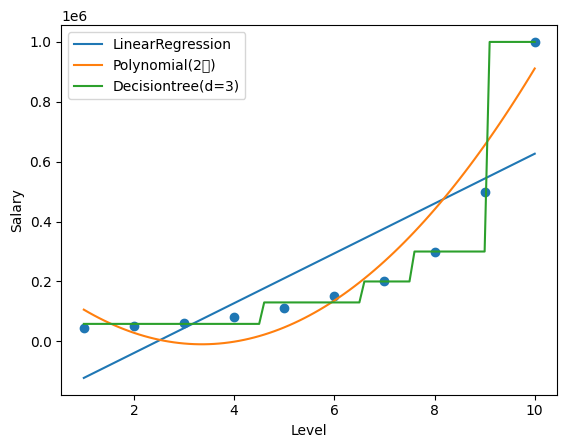

In [78]:
# ----------------------------
# 5) 예측 곡선(형태) 시각화
# ----------------------------
x_grid = np.arange(1, 10.01, 0.1).reshape(-1, 1)

plt.figure()
plt.scatter(X, y)  # 실제 데이터 점

for name, model in trained.items():
    y_grid_pred = model.predict(x_grid)
    plt.plot(x_grid, y_grid_pred, label=name)

plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

문제: 학습된 3개 모델로 동일한 입력에 대한 예측 비교하기

In [83]:
new_level = np.array([[6.5]])
for name, model in trained.items():
  print(name, "예측 Salary = ", int(model.predict(new_level)[0]))

LinearRegression 예측 Salary =  335474
Polynomial(2차) 예측 Salary =  196528
Decisiontree(d=3) 예측 Salary =  130000


```txt
같은 입력 인데 모델마다 예측이 다른 이유는 회귀 방식이 다르기 때문이다.
이 데이터는 LinearRegression이 성능도 좋고 6.5에 대한 예측도 가장  높게 나와
레벨-연봉의 선형 관계를 잘 반영한 것으로 보인다.
```